# Effectiveness of preprocessing when using SVM


In this notebook, I showed how preprocessing plays a critical role in the performance of SVMs, especially when using kernels like RBF that rely on distance calculations. The notebook presents two experiments on binary classification task: the first uses an artificial dataset, while the second applies the model to the Heart Disease dataset. In both cases, applying scikit-learn’s StandardScaler was essential to ensure that all features contributed equally. As a result, scaling significantly improved the model’s accuracy, highlighting that proper preprocessing is a key step when working with SVMs.

In [847]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

# Artificial Dataset

The dataset consists of 100 samples, each with two numerical features and a binary class label. It is generated using ```make_blobs```, which creates two Gaussian-like clusters with moderate spread and centers that I specified.

After the generation, the first feature is multiplied by 1000, introducing a severe scale disparity between the two features.

This intentional imbalance makes the dataset highly elongated along the first axis and is designed to demonstrate the importance of preprocessing, particularly feature scaling. Without scaling, models like an RBF SVM, which rely on distance calculations, become dominated by the larger feature and produce nearly linear boundaries. When scaling is applied, both features contribute more equally, often revealing a more accurate and nonlinear decision boundary.

In [848]:
# Create synthetic data with range disparity
X, y = make_blobs(n_samples=100,
                  n_features=2,
                  centers=[(0, -4), (0, 4)], cluster_std=[2.0, 4.0],
                  random_state=42)

X[:, 0] = X[:, 0] * 1000 # first feature has a range roughly 1000x larger

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

We can plot our dataset in order to see how values for Feature 1 can assume a very wide range, meanwhile Feature 2 range is much smaller.

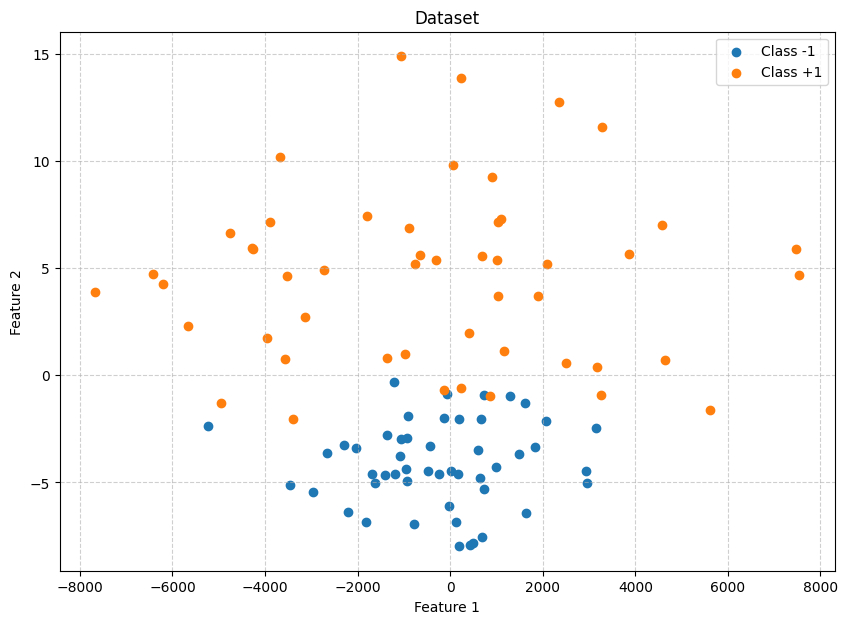

In [849]:
plt.figure(figsize=(10, 7))
plt.scatter(X[y==0, 0], X[y==0, 1], label='Class -1')
plt.scatter(X[y==1, 0], X[y==1, 1], label='Class +1')
plt.title("Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


In [850]:
def plot_decision_boundary(model, X, y):
  # Create a mesh grid
  x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
  y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
  xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                      np.linspace(y_min, y_max, 100))

  # Predict each point using the model
  Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
  Z = Z.reshape(xx.shape)
  plt.figure(figsize=(11, 7))

  # Draw filled contours to show predicted class regions
  plt.contourf(xx, yy, Z, alpha=0.4, cmap='coolwarm')

  # Plot the point on top
  plt.scatter(X[y==0, 0], X[y==0, 1], label='Class -1')
  plt.scatter(X[y==1, 0], X[y==1, 1], label='Class +1')
  plt.title("Decision Boundary")
  plt.xlabel("Feature 1")
  plt.ylabel("Feature 2")
  plt.legend()
  plt.grid(True, alpha=0.3)
  plt.show()

In this step, I use an SVM classifier with an RBF kernel to train and evaluate the model on the raw, unprocessed data. The focus here is not on optimizing hyperparameters such as ```C``` or ```gamma```; instead, the goal is simply to establish a baseline performance before applying any preprocessing techniques.

Since this notebook is primarily concerned with demonstrating the impact of preprocessing on model performance, tuning hyperparameters is intentionally skipped to keep the comparison straightforward and emphasize the effect of scaling rather than parameter optimization.

In [851]:
# Without Preprocessing (using raw data)
svc_raw = SVC(kernel='rbf', random_state=42)
svc_raw.fit(X_train, y_train)

y_predicted = svc_raw.predict(X_test)

accuracy_raw = accuracy_score(y_test, y_predicted)
print(f"Accuracy without preprocessing: {accuracy_raw:.2f}")

Accuracy without preprocessing: 0.67


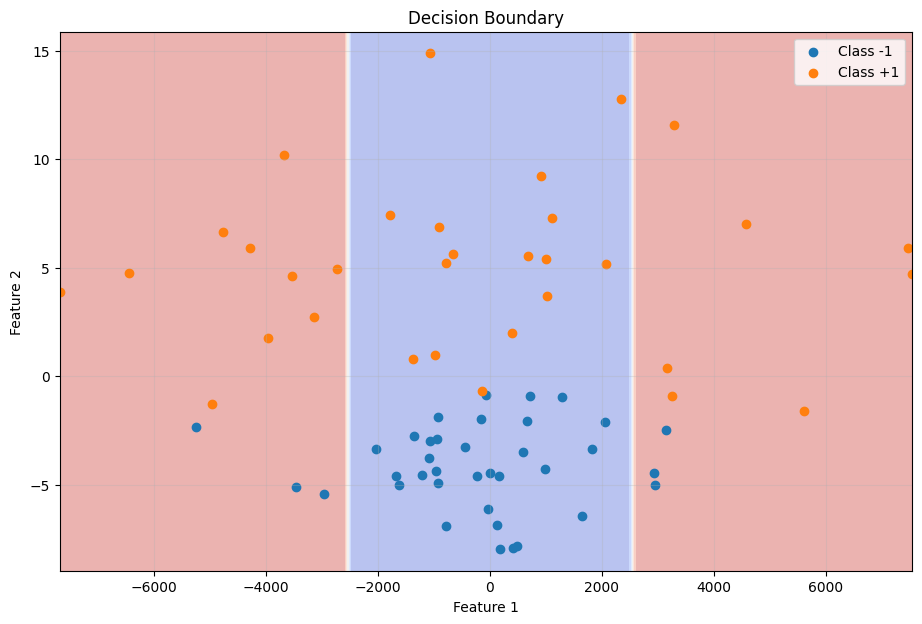

In [852]:
plot_decision_boundary(svc_raw, X_train, y_train)

Now we can move on and show how a simple ```StandardScaler()``` can improve the accuracy drastically. To do that I created a pipeline that first centers and scales the features in order to make them more comparable and then applies the same SVM classifier with an RBF kernel.

This preprocessing step helps the model treat all features equally during training, allowing the RBF kernel to capture more meaningful patterns in the data rather than being dominated by features with larger numerical ranges.



In [853]:
# With preprocessing
preprocessing_steps = [
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='rbf', random_state=42))
]

svc_scaled = Pipeline(steps=preprocessing_steps)
svc_scaled.fit(X_train, y_train)

accuracy_scaled = accuracy_score(y_test, svc_scaled.predict(X_test))
print(f"Accuracy with preprocessing: {accuracy_scaled:.2f}")

Accuracy with preprocessing: 0.90


After training the model with the scaled data, the decision boundary becomes noticeably more expressive and better aligned with the true structure of the dataset.

Note that the decision surface is non-linear because we are using a kernel evaluation, which performs an implicit transformation of the data into a higher-dimensional feature space. In this feature space, the SVM can find a linear separation that, when mapped back to the original input space, appears as a nonlinear boundary.

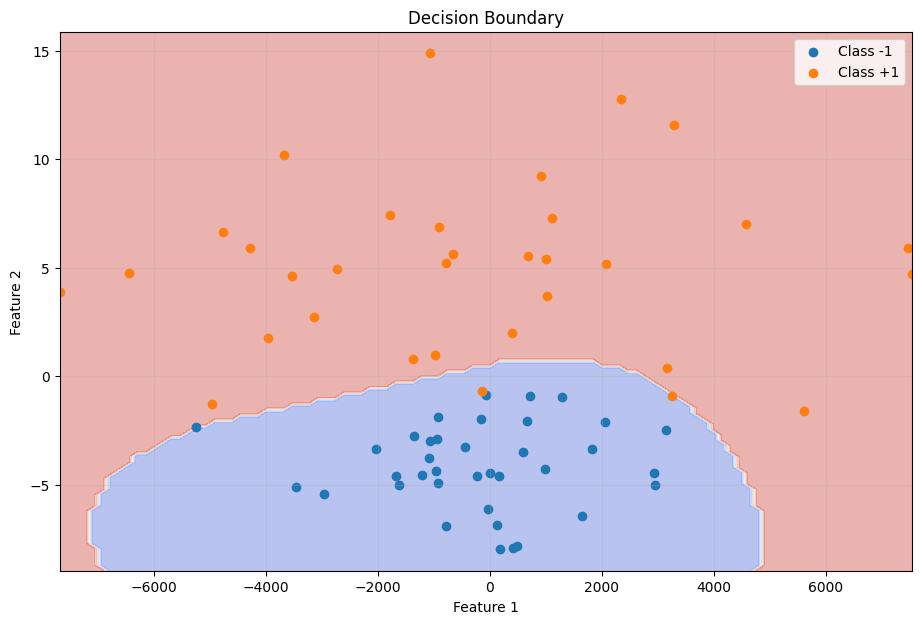

In [854]:
plot_decision_boundary(svc_scaled, X_train, y_train)

# Real dataset: Heart Disease

In [855]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("redwankarimsony/heart-disease-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'heart-disease-data' dataset.
Path to dataset files: /kaggle/input/heart-disease-data


In this dataset, we aim to predict whether a patient has heart disease. The dataset contains 14 features such as age, sex, chest pain type, resting blood pressure, serum cholesterol, fasting blood sugar, resting electrocardiographic results, maximum heart rate achieved, etc..

We can easily convert the task into a binary classification. In fact, we will convert every target ```num``` > 0 to 1.



In [856]:
df = pd.read_csv('/kaggle/input/heart-disease-data/heart_disease_uci.csv')
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


To illustrate that the features in the dataset have very different scales, we can use the descriptive statistics provided by Pandas. Calling ```df.describe().T``` will give a transposed summary table showing the count, mean, standard deviation, minimum, maximum, and quartiles for each feature.

In [857]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,920.0,460.500000,265.725422,1.0,230.75,460.5,690.25,920.0
age,920.0,53.510870,9.424685,28.0,47.00,54.0,60.00,77.0
trestbps,861.0,132.132404,19.066070,0.0,120.00,130.0,140.00,200.0
chol,890.0,199.130337,110.780810,0.0,175.00,223.0,268.00,603.0
thalch,865.0,137.545665,25.926276,60.0,120.00,140.0,157.00,202.0
oldpeak,858.0,0.878788,1.091226,-2.6,0.00,0.5,1.50,6.2
ca,309.0,0.676375,0.935653,0.0,0.00,0.0,1.00,3.0
num,920.0,0.995652,1.142693,0.0,0.00,1.0,2.00,4.0


Before proceeding, we need to encode some features and also replace missing values.

In [858]:
df['target'] = (df['num'] > 0).astype(int) # transforming in a binary classification task

df.drop(columns=['id', 'dataset', 'num'], inplace=True) # feature selection, we are dropping some irrelevant features

In [859]:
cols_with_invalid_zeros = ['trestbps', 'chol', 'thalch'] # these coloum has some missing values

df[cols_with_invalid_zeros] = df[cols_with_invalid_zeros].replace(0, np.nan)

# Fill numeric missing values with median
for col in df.select_dtypes(include=['float64', 'int64']).columns:
    df.fillna({col: df[col].median()}, inplace=True)

# to avoid futureWarning
pd.set_option('future.no_silent_downcasting', True)

# Fill categorical missing values with mode
for col in df.select_dtypes(include='object').columns:
    df.fillna({col: df[col].mode()[0]}, inplace=True)

# Encode categorical features
labelencoder = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = labelencoder.fit_transform(df[col])

In [860]:
X = df.drop(columns=['target'], axis=1)
y = df['target'] # target values
print(X.shape)
print(y.shape)

(920, 13)
(920,)


In [861]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

Now, we can train the model before without using the Standardization, then we will set a pipeline whose first step will be using the StandardScaler.

In [862]:
# Without StandardScaler
svc_raw = SVC(kernel='rbf', random_state=42)
svc_raw.fit(X_train, y_train)
y_predicted = svc_raw.predict(X_test)

accuracy_raw = accuracy_score(y_test, y_predicted)

In [863]:
# With StandardScaler
preprocessing_steps = [
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='rbf', random_state=42))
]

svc_scaled = Pipeline(steps=preprocessing_steps)
svc_scaled.fit(X_train, y_train)
y_predicted = svc_scaled.predict(X_test)

accuracy_scaled = accuracy_score(y_test, y_predicted)

In [864]:
print(f"Accuracy without StandardScaler: {accuracy_raw:.2f}")
print(f"Accuracy with StandardScaler: {accuracy_scaled:.2f}")

Accuracy without StandardScaler: 0.72
Accuracy with StandardScaler: 0.83


## Why preprocessing actually improve the performace?
Until now we used the ```StandardScaler()``` and saw an improvement in accuracy, to understand why we need to explore a little deeper what the ```StandardScaler()``` is doing to our data.

After applying the StandardScaler the mean for each feature will become 0 and the std equal to 1, in order to make the features comparable with each other.

So for each feature we calculate mean and std (note that we should compute these statistics only on the train set):
$$\hat{x}_{j}=\frac{1}{n}\sum_{i=1}^{n}x_{ij}\mathrm{~and~}\sigma_{j}=\sqrt{\frac{1}{n}\sum_{i=1}^{n}(x_{ij}-\hat{x}_{j})^{2}}$$

Then centering is applied (so the mean will be 0):
$$c(x_{ij})=x_{ij}-{\hat{x}}_{j}$$

Finally scaling is applied (so the std will be 1):
$$s(x_{ij})=\frac{c(x_{ij})}{\sigma_{j}}$$

In this notebook we used SVM with RBF kernel, this kernel computes similarity based on the squared Euclidean distance between two samples $\mathbf{x}$ and $\mathbf{z}$:
$$K(\mathbf{x},\mathbf{z})=\exp(-\gamma||\mathbf{x}-\mathbf{z}||^2)$$

The distance is sensitive to the scale of each feature, in fact if one feature has a much larger range than others (e.g., 0-1000 vs 0-1), it will dominate the distance calculation therefore this means that the RBF kernel will mostly consider the large-scale feature and ignore smaller ones. This aspect is key to understand why preprocessing, in particular standardization, is critical in this scenario.

# References

Slide Lez12 - Preprocessing

https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data

https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html

https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html

# Use of AI assistant
I used AI assistant to help me with english language in order to write better some sentences.